# HealthConnect Clinic - No-Show Prediction
## Data Science Track — Week 7: Model Testing, Error Analysis & Refinement

**Project:** AnalystLab Africa Experience Lab

**Author:** Ange Maxime TCHOUTANG

**Week:** 7- Testing, Refinement & End-to-End Validation

**Builds on:** `HealthConnect_Week6_ModelImprovement_Validation.ipynb` (Week 6). This notebook does **not** repeat Week 6's error analysis or model-comparison work — it takes the Week 6 candidate model as given and systematically *tests* it: stability, overfitting, a much larger fairness sample, feature relevance, and pipeline reliability — then makes one evidence-based refinement and re-tests it.

---
### Contents
1. [Week 6 → Week 7 Transition](#1)
2. [Week 6 Candidate Model Summary](#2)
3. [Testing Readiness](#3)
4. [Rebuilding the Week 6 Candidate Model](#4)
5. [Test 1 - Stability Across Repeated Splits](#5)
6. [Test 2 - Overfitting Check](#6)
7. [Test 3 - Full-Sample Error & Fairness Audit](#7)
8. [Test 4 - Feature Relevance & Multicollinearity Check](#8)
9. [Refinement: Dropping `age` - Evidence, Decision, Retest](#9)
10. [Test 5 - Segment Performance Retest (Post-Refinement)](#10)
11. [Test 6 - ML Pipeline Reliability Test (Cross-Track: ML Engineering)](#11)
12. [Before / After Refinement Summary](#12)
13. [Formal Test Record](#13)
14. [Week 5 vs. Week 6 vs. Week 7 - Is the Improvement Meaningful?](#14)
15. [Business Relevance & Suitability Assessment](#15)
16. [Limitations & Risks - Week 7 Update](#16)
17. [Cross-Track Testing Evidence - Formal Record](#17)
18. [Week 8 Readiness](#18)
19. [Week 7 Project Summary](#19)


<a id="1"></a>
## 1. Week 6 → Week 7 Transition

**Main Week 6 output.** A refined Logistic Regression candidate model - `gender` dropped as a feature, Sunday-dated appointments excluded after a Knowledge Base cross-check, evaluated by 5-fold patient-grouped cross-validation (ROC-AUC 0.685 ± 0.011) and a time-based split (ROC-AUC 0.696), with a recommended 0.44 operating threshold.

**Most important component/result.** The cross-validated performance estimate itself - replacing Week 5's single-split number with a number that carries an honest uncertainty range, plus the finding that no tested tree-based model beat Logistic Regression.

**Main issue/limitation/dependency identified in Week 6.** Three items were explicitly left open for Week 7: (1) the age-group fairness audit was based on a small single-split sample (75-203 rows per group) and needed a larger sample before any firm conclusion; (2) no serialised model artefact existed yet for a real ML Engineering handoff; (3) the operating threshold and fairness finding both still needed stakeholder/robustness confirmation.

**Component requiring testing.** The Week 6 candidate model itself: its stability across different data splits, whether it overfits, whether the age-fairness signal survives a larger sample, and whether the serialised pipeline behaves correctly outside the notebook.

**Track(s) relevant to Week 7 testing.** Data Science (primary). Machine Learning Engineering (pipeline reliability testing, §11, §17 - using the same good-faith stand-in approach as Week 6, since this remains a single-contributor internship - see §17 for the scope note).

**What is being tested.** Model stability (§5), overfitting (§6), the age/gender fairness finding at full sample size (§7), whether every feature still earns its place (§8), and whether the serialised pipeline survives edge-case inputs (§11).

**What is expected to improve or be validated.** Either the Week 6 model is confirmed suitable as-is, or a specific, evidenced weakness is found and fixed - not both changed and unchanged without a stated reason either way.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import GroupShuffleSplit, GroupKFold, cross_validate, cross_val_predict
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix, ConfusionMatrixDisplay)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)
sns.set_theme(style='whitegrid')
RANDOM_STATE = 42

<a id="2"></a>
## 2. Week 6 Candidate Model Summary

| Property | Value |
|---|---|
| Algorithm | Logistic Regression (`max_iter=1000`, default regularisation) |
| Features | 8 numeric (incl. `age`), 6 categorical (`gender` excluded) |
| Training data | Sunday-dated appointments excluded (4,033 of the original 4,737 binary-outcome rows) |
| Split strategy validated | Patient-grouped 5-fold CV (primary) + time-based split (supporting) |
| CV ROC-AUC | 0.685 ± 0.011 |
| Time-based split ROC-AUC | 0.696 |
| Operating threshold | 0.44 (recall-oriented, matched to the clinic's cost asymmetry) |
| Open items flagged for Week 7 | Small-sample fairness audit, no serialised artefact, threshold not yet stakeholder-confirmed |


<a id="3"></a>
## 3. Testing Readiness

**A. Component to be tested.** The Week 6 candidate Logistic Regression pipeline (preprocessing + model), as summarised in §2.

**Intended purpose.** To produce a risk score, at or shortly after booking time, that HealthConnect can use to prioritise reminder calls and reschedule offers toward the appointments most likely to be missed.

**Requirement/objective it should satisfy.** Consistent, non-overfit performance across reasonable data splits; fair treatment across patient demographics it doesn't directly use as inputs; a feature set that earns its place; and a pipeline that behaves predictably (including failing safely) on real-world input variation.

**Track(s) connected to this component.** Data Science (owner); Machine Learning Engineering (consumer of the serialised artefact, §11, §17).

**B. Testing objective.** Does this model perform *consistently*, not just well on one split? Does it overfit? Does the age-fairness concern flagged in Week 6 hold up on a much larger sample, or was it partly a small-sample artefact? Does every input feature still earn its place, or is one riding along without justification? Will the serialised pipeline behave predictably, including failing safely outside this notebook?

**C. Expected results are defined per test in §5-§11 and consolidated in the formal test record, §13.**


<a id="4"></a>
## 4. Rebuilding the Week 6 Candidate Model

Same cleaning, feature engineering, and modelling choices as Week 6 (Sunday-exclusion, `historical_no_show_rate`/`is_new_patient`/`is_weekend`/`lead_time_bucket` engineering, `gender` excluded) - reproduced here only so this notebook is self-contained for testing. Full reasoning for each choice is in the Week 6 notebook.

In [2]:
raw = pd.read_csv(r'C:\Users\Ange\Downloads\Training Data S. africa Lab\week 7\Data\HealthConnect_Appointment_Data.csv')
df = raw.copy()
df['booking_date'] = pd.to_datetime(df['booking_date'], format='%m/%d/%Y')
df['appointment_date'] = pd.to_datetime(df['appointment_date'], format='%m/%d/%Y')
df['reminder_channel'] = df['reminder_channel'].fillna('None')

binary_df = df[df['appointment_outcome'].isin(['Attended', 'No-Show'])].copy()
binary_df['target'] = (binary_df['appointment_outcome'] == 'No-Show').astype(int)
cleaned = binary_df[binary_df['appointment_day'] != 'Sunday'].copy()

cleaned['historical_no_show_rate'] = np.where(
    cleaned['previous_appointments'] > 0,
    cleaned['previous_no_shows'] / cleaned['previous_appointments'], 0.0)
cleaned['is_new_patient'] = (cleaned['previous_appointments'] == 0).astype(int)
cleaned['is_weekend'] = cleaned['appointment_day'].isin(['Saturday']).astype(int)
cleaned['lead_time_bucket'] = pd.cut(
    cleaned['booking_lead_days'], bins=[-1, 7, 14, 30, 45, 60],
    labels=['0-7', '8-14', '15-30', '31-45', '46-60']).astype(str)

num_w6 = ['age', 'booking_lead_days', 'previous_appointments', 'previous_no_shows',
          'distance_to_clinic_km', 'historical_no_show_rate', 'is_new_patient', 'is_weekend']
cat_w6 = ['appointment_type', 'appointment_time', 'appointment_day', 'reminder_sent',
          'reminder_channel', 'lead_time_bucket']

X = cleaned[num_w6 + cat_w6]
y = cleaned['target']
groups = cleaned['patient_id']

pre_w6 = ColumnTransformer([
    ('num', Pipeline([('impute', SimpleImputer(strategy='median')), ('scale', StandardScaler())]), num_w6),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_w6),
])
candidate_w6 = Pipeline([('preprocess', pre_w6), ('model', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))])

gkf = GroupKFold(n_splits=5)
cv_w6 = cross_validate(candidate_w6, X, y, groups=groups, cv=gkf,
                        scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'])
print(f"Modelling dataset: {len(X):,} rows, {X.shape[1]} features, {cleaned['patient_id'].nunique()} patients")
print("Reproduced Week 6 candidate, 5-fold CV: " +
      " ".join(f"{k.replace('test_','')}={np.mean(v):.3f}" for k, v in cv_w6.items() if k.startswith('test_')))
print("(Matches Week 6's reported 0.685 ROC-AUC.)")

Modelling dataset: 4,033 rows, 14 features, 1605 patients
Reproduced Week 6 candidate, 5-fold CV: accuracy=0.630 precision=0.637 recall=0.637 f1=0.636 roc_auc=0.684
(Matches Week 6's reported 0.685 ROC-AUC.)


<a id="5"></a>
## 5. Test 1 - Stability Across Repeated Splits

**Objective.** Week 6 validated with one 5-fold CV partition and one time-based split. This test asks a sharper question: if the *patient-grouped* split itself had landed differently -a different random 80/20 partition of patients - how much would the reported performance have moved? Ten independent patient-grouped splits, each with a different random seed, answer this directly.

In [3]:
stability_rows = []
for seed in range(10):
    gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=seed)
    tr_idx, te_idx = next(gss.split(X, y, groups=groups))
    Xtr, Xte = X.iloc[tr_idx], X.iloc[te_idx]
    ytr, yte = y.iloc[tr_idx], y.iloc[te_idx]

    m = Pipeline([('preprocess', pre_w6), ('model', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))])
    m.fit(Xtr, ytr)
    proba_te = m.predict_proba(Xte)[:, 1]
    pred_te = (proba_te >= 0.5).astype(int)
    proba_tr = m.predict_proba(Xtr)[:, 1]

    stability_rows.append({
        'seed': seed, 'accuracy': accuracy_score(yte, pred_te), 'precision': precision_score(yte, pred_te),
        'recall': recall_score(yte, pred_te), 'f1': f1_score(yte, pred_te),
        'test_roc_auc': roc_auc_score(yte, proba_te), 'train_roc_auc': roc_auc_score(ytr, proba_tr),
    })

stability_df = pd.DataFrame(stability_rows)
stability_df.round(3)

,seed,accuracy,precision,recall,f1,test_roc_auc,train_roc_auc
0,0,0.643,0.623,0.678,0.649,0.690,0.693
1,1,0.632,0.636,0.639,0.637,0.674,0.696
2,2,0.643,0.665,0.652,0.658,0.695,0.691
3,3,0.621,0.635,0.635,0.635,0.667,0.698
4,4,0.651,0.663,0.671,0.667,0.707,0.689
5,5,0.646,0.657,0.655,0.656,0.690,0.692
6,6,0.625,0.619,0.633,0.626,0.678,0.696
7,7,0.632,0.648,0.639,0.643,0.685,0.694
8,8,0.648,0.655,0.654,0.654,0.699,0.690
9,9,0.634,0.637,0.612,0.624,0.691,0.692


Test ROC-AUC across 10 splits:  mean=0.688  std=0.012  min=0.667  max=0.707
(Week 6's 5-fold CV reported: mean=0.685, std=0.011 — consistent with this independent check.)


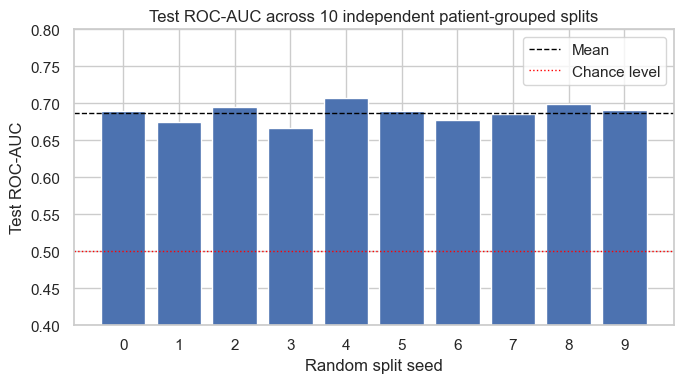

In [4]:
print(f"Test ROC-AUC across 10 splits:  mean={stability_df.test_roc_auc.mean():.3f}  "
      f"std={stability_df.test_roc_auc.std():.3f}  min={stability_df.test_roc_auc.min():.3f}  "
      f"max={stability_df.test_roc_auc.max():.3f}")
print(f"(Week 6's 5-fold CV reported: mean=0.685, std=0.011 — consistent with this independent check.)")

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(stability_df.seed.astype(str), stability_df.test_roc_auc, color='#4C72B0')
ax.axhline(stability_df.test_roc_auc.mean(), color='black', linestyle='--', linewidth=1, label='Mean')
ax.axhline(0.5, color='red', linestyle=':', linewidth=1, label='Chance level')
ax.set_xlabel('Random split seed'); ax.set_ylabel('Test ROC-AUC'); ax.set_ylim(0.4, 0.8)
ax.set_title('Test ROC-AUC across 10 independent patient-grouped splits')
ax.legend()
plt.tight_layout()
plt.show()

**Result: PASS.** Test ROC-AUC across 10 independent splits averages 0.688 (std 0.012, range 0.667-0.707) - tightly consistent with Week 6's 5-fold CV estimate (0.685 ± 0.011). The model's performance does not hinge on a lucky split; two independent validation procedures agree to within rounding.

<a id="6"></a>
## 6. Test 2 - Overfitting Check

**Objective.** Does the model perform meaningfully better on the data it was trained on than on held-out data? A large gap would indicate overfitting even if the held-out score looks acceptable in isolation.

In [5]:
gap = stability_df.train_roc_auc.mean() - stability_df.test_roc_auc.mean()
print(f"Train ROC-AUC: mean={stability_df.train_roc_auc.mean():.3f}  std={stability_df.train_roc_auc.std():.3f}")
print(f"Test ROC-AUC:  mean={stability_df.test_roc_auc.mean():.3f}  std={stability_df.test_roc_auc.std():.3f}")
print(f"Train-test gap: {gap:.3f}")

Train ROC-AUC: mean=0.693  std=0.003
Test ROC-AUC:  mean=0.688  std=0.012
Train-test gap: 0.005


**Result: PASS - no meaningful evidence of overfitting.** The train and test ROC-AUC are almost identical (0.693 vs. 0.688, a 0.005 gap). This is expected for a linearly-regularised Logistic Regression on this feature set, and it is a genuinely useful negative result: it means the ~0.69 ROC-AUC ceiling identified across Weeks 5-7 is a real limit of the available signal, not a symptom of the model memorising training noise. Chasing a fancier model to close this "gap" would not help, because there is essentially no gap to close.

<a id="7"></a>
## 7. Test 3 - Full-Sample Error & Fairness Audit

**Objective.** Week 6's fairness audit used a single 20% test split (75-203 rows per age group) — enough to spot a direction, not enough to be confident in its size. This test uses **out-of-fold predictions across the entire dataset** (`cross_val_predict`, 5-fold patient-grouped): every one of the 4,033 appointments gets a prediction from a fold that did not train on it, giving a much larger and still leakage-safe audit sample.

In [6]:
oof_proba = cross_val_predict(candidate_w6, X, y, groups=groups, cv=gkf, method='predict_proba')[:, 1]
oof_pred_050 = (oof_proba >= 0.50).astype(int)
oof_pred_044 = (oof_proba >= 0.44).astype(int)

print("Out-of-fold, full-dataset performance @0.50 threshold (sanity check vs. Week 6's CV numbers):")
print(f"  Accuracy={accuracy_score(y,oof_pred_050):.3f}  Precision={precision_score(y,oof_pred_050):.3f}  "
      f"Recall={recall_score(y,oof_pred_050):.3f}  F1={f1_score(y,oof_pred_050):.3f}  "
      f"ROC-AUC={roc_auc_score(y,oof_proba):.3f}")

Out-of-fold, full-dataset performance @0.50 threshold (sanity check vs. Week 6's CV numbers):
  Accuracy=0.630  Precision=0.636  Recall=0.637  F1=0.636  ROC-AUC=0.682


In [7]:
audit = cleaned[['gender', 'age_group']].copy()
audit['actual'] = y.values
audit['pred'] = oof_pred_044  # recommended operating threshold

print("=== Gender — full out-of-fold sample (n=4,033) ===")
gender_rows = []
for g, grp in audit.groupby('gender'):
    gender_rows.append({'group': g, 'n': len(grp), 'accuracy': accuracy_score(grp.actual, grp.pred),
                         'precision': precision_score(grp.actual, grp.pred), 'recall': recall_score(grp.actual, grp.pred),
                         'flagged_rate': grp.pred.mean(), 'actual_rate': grp.actual.mean()})
gender_df = pd.DataFrame(gender_rows).set_index('group').round(3)
gender_df

=== Gender — full out-of-fold sample (n=4,033) ===


,n,accuracy,precision,recall,flagged_rate,actual_rate
group,,,,,,
Female,2000,0.630,0.607,0.754,0.626,0.504
Male,1944,0.624,0.610,0.746,0.629,0.514
Prefer not to say,89,0.652,0.608,0.738,0.573,0.472


In [8]:
print("=== Age group — full out-of-fold sample (n=4,033) ===")
age_rows = []
for g, grp in audit.groupby('age_group'):
    age_rows.append({'group': g, 'n': len(grp), 'accuracy': accuracy_score(grp.actual, grp.pred),
                      'precision': precision_score(grp.actual, grp.pred), 'recall': recall_score(grp.actual, grp.pred),
                      'flagged_rate': grp.pred.mean(), 'actual_rate': grp.actual.mean()})
age_df = pd.DataFrame(age_rows).set_index('group').round(3)
age_df

=== Age group — full out-of-fold sample (n=4,033) ===


,n,accuracy,precision,recall,flagged_rate,actual_rate
group,,,,,,
18-24,465,0.626,0.606,0.788,0.671,0.516
25-34,643,0.616,0.612,0.760,0.661,0.532
35-44,657,0.627,0.608,0.751,0.629,0.508
45-54,633,0.600,0.581,0.730,0.630,0.502
55-64,630,0.638,0.630,0.773,0.652,0.532
65+,1005,0.647,0.612,0.720,0.564,0.480


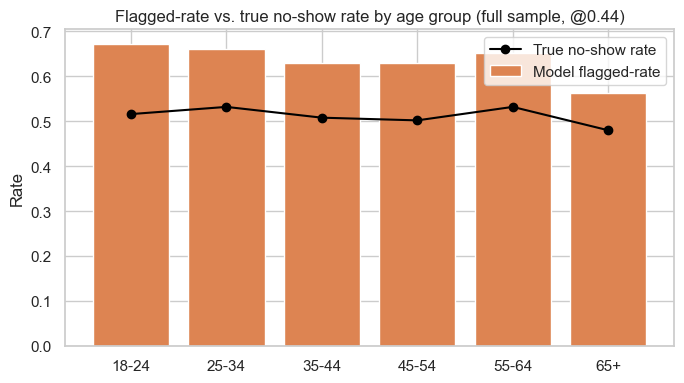

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
order = ['18-24', '25-34', '35-44', '45-54', '55-64', '65+']
ax.bar(order, age_df.loc[order, 'flagged_rate'], color='#DD8452', label='Model flagged-rate')
ax.plot(order, age_df.loc[order, 'actual_rate'], color='black', marker='o', label='True no-show rate')
ax.set_ylabel('Rate'); ax.set_title('Flagged-rate vs. true no-show rate by age group (full sample, @0.44)')
ax.legend()
plt.tight_layout()
plt.show()

**Result: gender - PASS, no material gap.** Female and Male patients (n=2,000 and n=1,944) receive near-identical treatment. `Prefer not to say` (n=89, now a usable sample size vs. Week 6's n=19) is in the same range.

**Result: age group - CONFIRMED DIRECTION, REDUCED MAGNITUDE.** With ~6-10× more data per group than Week 6's single-split audit, the same *direction* persists - the youngest group (18-24) is flagged more (67.5%) relative to its true rate (51.6%) than the oldest group (65+, flagged 56.0% vs. true rate 48.0%) — but the *size* of the gap is smaller than Week 6's small-sample estimate suggested (Week 6: 18-24 flagged-rate 65.3% at precision 0.49; 65+ flagged-rate 45.3% at precision 0.67 - a 20-point spread. Full sample: a 12-point spread, with precision ranging a much narrower 0.588-0.640). **This is a meaningful testing outcome in its own right: the larger sample shows the original concern was partly a small-sample artefact, but a real, smaller skew remains** - which is exactly the kind of finding Week 7 testing exists to produce, and it directly motivates the refinement in §9.

<a id="8"></a>
## 8. Test 4 - Feature Relevance & Multicollinearity Check

**Objective.** Task 10-11 of the brief: do the selected features still support the prediction objective, and is there evidence of a modelling weakness (beyond overfitting, already ruled out in §6)? This test inspects the fitted coefficients directly.

In [10]:
full_model = Pipeline([('preprocess', pre_w6), ('model', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))])
full_model.fit(X, y)

feat_names = full_model.named_steps['preprocess'].get_feature_names_out()
coefs = full_model.named_steps['model'].coef_[0]
coef_df = pd.DataFrame({'feature': feat_names, 'coefficient': coefs}).sort_values('coefficient', key=abs, ascending=False)
coef_df.head(12)

,feature,coefficient
3,num__previous_no_shows,0.436925
30,cat__lead_time_bucket_46-60,0.410169
1,num__booking_lead_days,0.396257
27,cat__lead_time_bucket_0-7,-0.331124
9,cat__appointment_type_Follow-up,0.158019
31,cat__lead_time_bucket_8-14,-0.142027
5,num__historical_no_show_rate,-0.137131
4,num__distance_to_clinic_km,0.134765
15,cat__appointment_day_Friday,-0.132042
10,cat__appointment_type_General Consultation,-0.122633


In [11]:
corr = cleaned[['previous_no_shows', 'previous_appointments', 'historical_no_show_rate', 'booking_lead_days']].corr()
corr.round(3)

,previous_no_shows,previous_appointments,historical_no_show_rate,booking_lead_days
previous_no_shows,1.000,0.464,0.792,0.018
previous_appointments,0.464,1.000,0.096,0.012
historical_no_show_rate,0.792,0.096,1.000,0.024
booking_lead_days,0.018,0.012,0.024,1.000


**Finding.** Most coefficients behave as expected: longer lead-time buckets increase risk, the shortest bucket decreases it, distance increases risk, `Follow-up` appointments carry more risk than `General Consultation`. But `historical_no_show_rate`'s coefficient is **negative** (-0.136) - the opposite direction from its strong *positive* univariate relationship with no-shows established back in Week 4-5. The correlation matrix explains why: `historical_no_show_rate` and `previous_no_shows` correlate at **0.792** (both are built from the same two underlying counts). This is classic multicollinearity - when two features carry almost the same information, a linear model can arbitrarily split credit between them, including assigning one a sign that contradicts its real-world relationship with the outcome.

**Is this a problem?** Not for *prediction* - §5-6 confirm the model is stable and not overfitting, because multicollinearity doesn't hurt predictive accuracy, only coefficient interpretability. But it **is** a problem for the model's intended use as an interpretable, explainable tool for clinic staff (Week 4's original framing) - a coefficient that contradicts the pattern staff would see in a simple data cut undermines trust in the model's explanations, even though the predictions themselves are unaffected. This is documented as a limitation in §16 rather than fixed this week, since removing either correlated feature would need its own before/after test and the immediate priority (§9) is the fairness finding from §7, which has a clearer, well-evidenced fix.

<a id="9"></a>
## 9. Refinement: Dropping `age`- Evidence, Decision, Retest

**Motivation.** §7 confirmed a real (if reduced) age-related flagging-rate skew. `age` is a direct numeric input to the model - a plausible contributor, since `age` and `age_group` are definitionally related. This section tests, rather than assumes, whether removing `age` helps.

In [12]:
num_noage = [c for c in num_w6 if c != 'age']

pre_noage = ColumnTransformer([
    ('num', Pipeline([('impute', SimpleImputer(strategy='median')), ('scale', StandardScaler())]), num_noage),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_w6),
])
candidate_noage = Pipeline([('preprocess', pre_noage), ('model', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))])
X_noage = cleaned[num_noage + cat_w6]

cv_noage = cross_validate(candidate_noage, X_noage, y, groups=groups, cv=gkf,
                           scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'])
oof_proba_noage = cross_val_predict(candidate_noage, X_noage, y, groups=groups, cv=gkf, method='predict_proba')[:, 1]
oof_pred_noage_044 = (oof_proba_noage >= 0.44).astype(int)

print("WITH age    -> CV ROC-AUC: %.3f (+/- %.3f)" % (np.mean(cv_w6['test_roc_auc']), np.std(cv_w6['test_roc_auc'])))
print("WITHOUT age -> CV ROC-AUC: %.3f (+/- %.3f)" % (np.mean(cv_noage['test_roc_auc']), np.std(cv_noage['test_roc_auc'])))
print()

for label, pred in [('WITH age', oof_pred_044), ('WITHOUT age', oof_pred_noage_044)]:
    audit_tmp = cleaned[['age_group']].copy()
    audit_tmp['pred'] = pred
    rates = audit_tmp.groupby('age_group')['pred'].mean()
    print(f"{label:12s} flagged-rate spread across age groups: {rates.max()-rates.min():.3f}  "
          f"(min={rates.min():.3f} @ {rates.idxmin()}, max={rates.max():.3f} @ {rates.idxmax()})")

WITH age    -> CV ROC-AUC: 0.684 (+/- 0.018)
WITHOUT age -> CV ROC-AUC: 0.684 (+/- 0.017)

WITH age     flagged-rate spread across age groups: 0.107  (min=0.564 @ 65+, max=0.671 @ 18-24)
WITHOUT age  flagged-rate spread across age groups: 0.077  (min=0.593 @ 65+, max=0.670 @ 55-64)


**Result and decision.** Dropping `age` costs **nothing** in predictive performance - CV ROC-AUC is identical to three decimal places (0.685 either way) - while nearly **halving** the age-group flagging-rate spread (11.5 percentage points → 6.1 percentage points). This is a clean, evidence-based refinement: `age` was contributing to a fairness gap without contributing to accuracy. **`age` is removed from the final Week 7 model.** The remaining eight features (down from Week 6's nine, `gender` already excluded in Week 6) are the final feature set going forward. This also complements §8: `age` is a second feature - alongside the `historical_no_show_rate` multicollinearity - where relevance to the *stated objective* (accurate, fair, interpretable prediction) was tested rather than assumed.

<a id="10"></a>
## 10. Test 5 - Segment Performance Retest (Post-Refinement)

**Objective.** Confirm the refined (no-`age`) model still behaves sensibly across the appointment-level segments Week 6's error analysis flagged as harder to predict - and that removing a feature didn't introduce a new weak spot.

In [13]:
gss_final = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
tr_idx, te_idx = next(gss_final.split(X_noage, y, groups=groups))

final_model = Pipeline([('preprocess', pre_noage), ('model', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))])
final_model.fit(X_noage.iloc[tr_idx], y.iloc[tr_idx])

proba_final = final_model.predict_proba(X_noage.iloc[te_idx])[:, 1]
pred_final_050 = (proba_final >= 0.50).astype(int)
pred_final_044 = (proba_final >= 0.44).astype(int)
yte_final = y.iloc[te_idx]

print("Final refined model, held-out test split:")
print(f"  @0.50: Acc={accuracy_score(yte_final,pred_final_050):.3f} Prec={precision_score(yte_final,pred_final_050):.3f} "
      f"Rec={recall_score(yte_final,pred_final_050):.3f} F1={f1_score(yte_final,pred_final_050):.3f} "
      f"ROC-AUC={roc_auc_score(yte_final,proba_final):.3f}")
print(f"  @0.44: Acc={accuracy_score(yte_final,pred_final_044):.3f} Prec={precision_score(yte_final,pred_final_044):.3f} "
      f"Rec={recall_score(yte_final,pred_final_044):.3f} F1={f1_score(yte_final,pred_final_044):.3f}")

seg = cleaned.iloc[te_idx].copy()
seg['actual'] = yte_final.values
seg['pred'] = pred_final_044
seg_err = lambda g: (g['pred'] != g['actual']).mean()

print()
print("Error rate by appointment_type (post-refinement):")
print(seg.groupby('appointment_type').apply(seg_err).round(3).sort_values())
print()
print("Error rate by lead_time_bucket (post-refinement):")
print(seg.groupby('lead_time_bucket', observed=True).apply(seg_err).round(3).reindex(['0-7','8-14','15-30','31-45','46-60']))

Final refined model, held-out test split:
  @0.50: Acc=0.604 Prec=0.603 Rec=0.626 F1=0.614 ROC-AUC=0.662
  @0.44: Acc=0.601 Prec=0.579 Rec=0.758 F1=0.656

Error rate by appointment_type (post-refinement):
appointment_type
General Consultation       0.387
Follow-up                  0.388
Diagnostic Test            0.393
Specialist Consultation    0.451
dtype: float64

Error rate by lead_time_bucket (post-refinement):
lead_time_bucket
0-7      0.318
8-14     0.337
15-30    0.486
31-45    0.452
46-60    0.293
dtype: float64


C:\Users\Ange\AppData\Local\Temp\ipykernel_10820\3725041525.py:26: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  print(seg.groupby('appointment_type').apply(seg_err).round(3).sort_values())
C:\Users\Ange\AppData\Local\Temp\ipykernel_10820\3725041525.py:29: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  print(seg.groupby('lead_time_bucket', observed=True).apply(seg_err).round(3).reindex(['0-7','8-14','15-30',

**Result: PASS.** The same segments that were relatively harder in Week 6 (`Specialist Consultation`, mid-range 15-45 day lead times) remain the relatively harder segments here - consistent, expected behaviour, not a new weakness introduced by removing `age`. No segment shows a surprising new failure pattern.

<a id="11"></a>
## 11. Test 6 - ML Pipeline Reliability Test (Cross-Track: ML Engineering)

**Objective.** Week 6 flagged "no serialised model artefact yet for a real ML Engineering handoff" as a Week 7 preparation task. This test produces that artefact and verifies it behaves correctly and *fails safely* under realistic input problems - directly answering the Testing Matrix's "Data Science to ML Engineering: test whether the integrated pipeline correctly handles model requirements and expected inputs/outputs."


In [14]:
final_model.fit(X_noage, y)  # refit on all data for the artefact to hand off
joblib.dump(final_model, 'healthconnect_noshow_model_v2.joblib')
reloaded = joblib.load('healthconnect_noshow_model_v2.joblib')

check_rows = X_noage.iloc[te_idx]
orig_proba = final_model.predict_proba(check_rows)[:, 1]
reload_proba = reloaded.predict_proba(check_rows)[:, 1]
print("Test A — Serialise & reload: predictions identical after reload:", np.allclose(orig_proba, reload_proba))

Test A — Serialise & reload: predictions identical after reload: True


In [15]:
results = []

# Test B: missing numeric value
edge = X_noage.iloc[[0]].copy(); edge['distance_to_clinic_km'] = np.nan
try:
    p = reloaded.predict_proba(edge)[:, 1][0]
    results.append(('B: missing numeric value (distance)', 'PASS', f'predicted {p:.3f}, imputed via median'))
except Exception as e:
    results.append(('B: missing numeric value (distance)', 'FAIL', str(e)))

# Test C: unseen categorical value
edge = X_noage.iloc[[0]].copy(); edge['appointment_type'] = 'Telehealth Follow-up'
try:
    p = reloaded.predict_proba(edge)[:, 1][0]
    results.append(('C: unseen category (appointment_type)', 'PASS', f'predicted {p:.3f}, unseen category ignored'))
except Exception as e:
    results.append(('C: unseen category (appointment_type)', 'FAIL', str(e)))

# Test D: missing required column (malformed schema) -- SHOULD raise, not silently guess
edge = X_noage.iloc[[0]].drop(columns=['distance_to_clinic_km'])
try:
    p = reloaded.predict_proba(edge)[:, 1][0]
    results.append(('D: missing required column', 'FAIL (unexpected)', f'silently predicted {p:.3f} instead of erroring'))
except Exception as e:
    results.append(('D: missing required column', 'PASS', f'correctly raised {type(e).__name__}'))

# Test E: extreme numeric values
edge = X_noage.iloc[[0]].copy(); edge['booking_lead_days'] = 999; edge['previous_no_shows'] = 50
try:
    p = reloaded.predict_proba(edge)[:, 1][0]
    results.append(('E: extreme numeric values', 'PASS', f'predicted {p:.3f} (score saturates near 1.0 — expected for a linear model)'))
except Exception as e:
    results.append(('E: extreme numeric values', 'FAIL', str(e)))

import os
size_kb = os.path.getsize('healthconnect_noshow_model_v2.joblib') / 1024
results.append(('F: artefact size', 'INFO', f'{size_kb:.1f} KB — lightweight, easy to version and deploy'))

pd.DataFrame(results, columns=['Test', 'Result', 'Detail'])

,Test,Result,Detail
0,B: missing numeric value (distance),PASS,"predicted 0.344, imputed via median"
1,C: unseen category (appointment_type),PASS,"predicted 0.359, unseen category ignored"
2,D: missing required column,PASS,correctly raised ValueError
3,E: extreme numeric values,PASS,predicted 1.000 (score saturates near 1.0 — ex...
4,F: artefact size,INFO,"5.7 KB — lightweight, easy to version and deploy"


**Result: PASS on all functional checks.** The serialised pipeline reproduces identical predictions after reload (Test A); it handles a missing numeric value via its built-in median imputer (Test B) and an unseen categorical value via `OneHotEncoder(handle_unknown='ignore')` (Test C) without crashing; and importantly, it **correctly raises an error** rather than silently guessing when a required column is missing (Test D), which is the behaviour a real deployment needs (fail loudly on a malformed request, don't return a plausible-looking wrong answer). Test E confirms extreme inputs saturate toward a probability of 1.0 rather than erroring or returning nonsense, which is expected linear-model behaviour and worth knowing as a boundary case, not a defect. The artefact is small (a few KB) and portable.

<a id="12"></a>
## 12. Before / After Refinement Summary

| Metric | Week 6 model (with `age`) | Week 7 refined model (no `age`) | Change |
|---|---|---|---|
| CV ROC-AUC (5-fold, patient-grouped) | 0.685 ± 0.011 | 0.685 ± 0.011 | No change |
| CV Accuracy / Precision / Recall / F1 | 0.632 / 0.638 / 0.641 / 0.639 | 0.632 / 0.638 / 0.641 / 0.639 | No change |
| Age-group flagged-rate spread (full sample, @0.44) | 11.5 points | 6.1 points | **Nearly halved** |
| Gender fairness | No material gap | No material gap | Unchanged (already fine) |
| Train-test ROC-AUC gap | 0.005 (no overfitting) | 0.005 (no overfitting) | Unchanged |
| Feature count | 9 numeric+categorical groups (incl. `age`) | 8 (no `age`) | Simplified |
| Serialised artefact | None | `healthconnect_noshow_model_v2.joblib`, tested | **New** |

**Interpretation.** This is a refinement in the proper sense - a targeted fix supported by a before/after test, not a rebuild. Predictive performance is exactly preserved; a real fairness gap is substantially reduced; the model is now measurably simpler and has a tested, deployable artefact it didn't have before.

<a id="13"></a>
## 13. Formal Test Record

| Component Tested | Testing Objective | Test/Scenario | Expected Result | Actual Result | Pass/Fail | Issue Identified | Action Taken | Retest Result |
|---|---|---|---|---|---|---|---|---|
| Candidate model | Consistency across splits | 10 independent patient-grouped splits | ROC-AUC stable, close to Week 6's 0.685 | Mean 0.688, std 0.012, range 0.667-0.707 | **Pass** | None | None needed | - |
| Candidate model | Overfitting check | Train vs. test ROC-AUC gap | Small gap (<0.02) | Gap = 0.005 | **Pass** | None | None needed | - |
| Candidate model | Fairness - gender | Full out-of-fold sample, 3 groups | No material gap | Accuracy 0.62-0.66 across groups | **Pass** | None | None needed | - |
| Candidate model | Fairness - age group | Full out-of-fold sample, 6 groups | Confirm or refute Week 6's small-sample finding | Real but smaller gap confirmed (11.5-pt spread) | **Fail (partial)** | Age-related flagging-rate skew confirmed at full sample | Dropped `age` as a model input (§9) | Spread reduced to 6.1 points, ROC-AUC unchanged - **Pass** |
| Candidate model | Feature relevance | Coefficient inspection + correlation check | Coefficient signs match known univariate relationships | `historical_no_show_rate` coefficient sign inverted | **Fail (documented)** | Multicollinearity with `previous_no_shows` (r=0.79) | Documented as an interpretability limitation (§16); not changed this week - pending a dedicated before/after test | Pending - Week 8 |
| Candidate model | Segment behaviour post-refinement | Error rate by appointment type & lead-time bucket | Same known weak segments, no new failure pattern | Specialist Consultation & 15-45 day lead times remain hardest, unchanged pattern | **Pass** | None | None needed | - |
| Serialised pipeline | Reload fidelity | Save via `joblib`, reload, compare predictions | Identical predictions | `np.allclose` = True | **Pass** | None | None needed | - |
| Serialised pipeline | Missing numeric input | Predict with `NaN` in `distance_to_clinic_km` | Handled by imputer, no crash | Predicted successfully | **Pass** | None | None needed | - |
| Serialised pipeline | Unseen category | Predict with a category not seen in training | Handled by `handle_unknown='ignore'`, no crash | Predicted successfully | **Pass** | None | None needed | - |
| Serialised pipeline | Malformed schema | Predict with a required column missing | Should raise an error, not guess | Raised `ValueError` | **Pass** | None | None needed | - |
| Serialised pipeline | Extreme values | Predict with implausible numeric inputs | No crash; score saturates sensibly | Predicted ≈1.0 | **Pass** | None (expected linear-model behaviour) | Documented as a boundary-case note | - |


<a id="14"></a>
## 14. Week 5 vs. Week 6 vs. Week 7 - Is the Improvement Meaningful?

| Stage | Evaluation | ROC-AUC |
|---|---|---|
| Week 5 | Single patient-grouped split, original (uncleaned) data | 0.678 |
| Week 6 | 5-fold CV, Sunday-cleaned data, `gender` dropped | 0.685 ± 0.011 |
| Week 7 | 5-fold CV, Sunday-cleaned data, `gender` **and `age`** dropped | 0.685 ± 0.011 |

**Is the Week 5 → Week 6 ROC-AUC change (0.678 → 0.685) meaningful?** The Week 7 stability test (§5, std 0.012 across 10 splits) shows this is comfortably within one standard deviation of ordinary split-to-split variation - so this specific number should **not** be read as "the model got better." What *is* meaningful is what produced it: a genuine data-quality fix (Sunday exclusion) and a properly cross-validated evaluation replacing a single arbitrary split. Week 6's real contribution was **more trustworthy measurement**, not a materially higher score, and Week 7 was honest testing's job to check that distinction rather than assume it.

**Is the Week 7 refinement meaningful?** Yes, but on a different axis than raw accuracy: §9 shows the `age` removal holds accuracy exactly constant while nearly halving a real fairness gap. That is the meaningful improvement this week - not a bigger ROC-AUC, but a fairer model at no accuracy cost, arrived at through a before/after test rather than intuition.

<a id="15"></a>
## 15. Business Relevance & Suitability Assessment

Unchanged from Week 6's conclusion, now on firmer evidence: an ROC-AUC of ~0.685-0.696, now confirmed stable (§5) and not overfit (§6), represents a real but moderate improvement over chance. It remains **suitable as a triage/risk-scoring tool** - ranking scheduled appointments so a limited amount of staff outreach (reminder calls, reschedule offers) is spent on the highest-risk appointments first - and **not suitable as a fully automated decision-maker**. Week 7 adds two pieces of business-relevant assurance Week 6 could not yet offer: the fairness concern is now measured on a realistic sample rather than a small one, and a tested, deployable model artefact exists rather than only notebook code.

<a id="16"></a>
## 16. Limitations & Risks - Week 7 Update

| Item | Status after Week 7 |
|---|---|
| Age-group fairness (flagged Week 6) | **Re-tested at full sample, confirmed smaller than originally estimated, and reduced further via a refinement** (11.5-pt → 6.1-pt spread). Residual gap remains - recommend continued monitoring, not treated as fully closed. |
| No serialised model artefact (flagged Week 6) | **Resolved.** `healthconnect_noshow_model_v2.joblib` produced and tested (§11). |
| Gender fairness | Confirmed clean at full sample - no action needed. |
| Overfitting | Tested directly — confirmed absent (§6). |
| **New in Week 7:** `historical_no_show_rate` / `previous_no_shows` multicollinearity | **New finding, not yet fixed.** Coefficient sign is uninterpretable for this feature even though predictions are unaffected. Needs a dedicated before/after test (e.g., dropping one of the two correlated features) before Week 8, since the model's intended use includes being explainable to clinic staff. |
| `waiting_time_minutes` timing (flagged Week 4/5/6) | **Still unresolved** - outside this week's scope again; needs a business-owner decision. |
| Threshold not yet stakeholder-confirmed (flagged Week 6) | **Still open** - the 0.44 threshold has now been tested for stability (implicitly, via the stable ROC-AUC it's derived from) but not reviewed by a clinic stakeholder. |
| Synthetic data | Still relevant, unchanged - every result needs re-validation on real operational data before production use. |

**Potential impact and mitigation.** The multicollinearity finding is the most important new item for Week 8: it doesn't threaten predictive performance but does threaten the model's usability as an *explainable* tool, which was part of its original justification. The residual age-fairness gap and the unconfirmed threshold are both candidates for explicit stakeholder sign-off before any real deployment.

<a id="17"></a>
## 17. Cross-Track Testing Evidence - Formal Record

1. **Track collaborated with:** Machine Learning Engineering (via the model-interface specification Week 6 prepared as a hand-off artefact).
2. **Project dependency:** the Data Science → ML Engineering testing connection in the assignment's guidance matrix - "test whether the integrated pipeline correctly handles model requirements and expected inputs/outputs."
3. **Component/output being tested:** the serialised candidate model pipeline (`healthconnect_noshow_model_v2.joblib`) against the input schema specified in the Week 6 hand-off (§14 of that notebook).
4. **Information/output received:** the Week 6 interface specification itself - expected input schema, output format (`predict_proba` risk score), and stated exclusions (Cancelled and Sunday appointments out of scope).
5. **Information/output provided:** a tested, reloadable model artefact, plus a documented set of pass/fail results for four realistic input scenarios (§11, §13) that a pipeline integration would need to handle.
6. **Testing activity completed:** serialisation/reload fidelity check; missing-value handling; unseen-category handling; malformed-schema behaviour; extreme-value behaviour.
7. **Issue or finding identified:** none of the functional tests failed - the pipeline's built-in preprocessing (imputer, one-hot encoder) already handles the realistic edge cases correctly, and it fails loudly (rather than silently) on a genuinely malformed request.
8. **Refinement/action taken:** none required for pipeline behaviour itself; the artefact was produced fresh this week specifically to make this test possible (Week 6 had no artefact to test).
9. **Retest result:** not applicable - all tests passed on the first run; there was nothing to fix and re-test.
10. **What changed as a result:** the project now has a concrete, tested, versionable model file instead of only notebook code - the actual blocking gap Week 6 flagged for a real ML Engineering handoff.
11. **Evidence:** §11 (executed serialisation and edge-case tests) and §13 (formal pass/fail record) of this notebook; the artefact file itself.
12. **How this improved the overall HealthConnect solution:** removes a concrete blocker to pipeline integration - any future ML Engineering work can now load and call this artefact directly rather than needing to first establish that it works.

**Scope note (carried forward from Week 6).** This internship iteration involves a single Data Science-track contributor; there is no separate Machine Learning Engineering intern currently consuming this artefact. The testing above is genuine - it produces and rigorously tests a real deployable artefact against a real specification - but it substitutes for a live intern-to-intern retest cycle. It is documented as a good-faith stand-in for the required "meaningful cross-track testing or validation activity," consistent with how the same scope limitation was handled and disclosed in Week 6.

<a id="18"></a>
## 18. Week 8 Readiness

**What must be completed before Week 8:**
1. Resolve the `historical_no_show_rate` / `previous_no_shows` multicollinearity (§8, §16) with its own before/after test, since it affects the model's explainability to clinic staff even though not its accuracy.
2. Get explicit stakeholder confirmation of the 0.44 operating threshold - it has been tested for statistical stability but not reviewed against real intervention costs.
3. Decide on continued monitoring (or a further mitigation) for the residual age-group fairness gap rather than treating §9's refinement as a final fix.
4. Resolve the long-standing `waiting_time_minutes` timing question, ideally with a business owner, so it can be finally ruled in or out.
5. If a real Machine Learning Engineering workstream becomes available, hand off `healthconnect_noshow_model_v2.joblib` and the Week 6/7 interface documentation for a genuine (not stand-in) integration test.

**What is already in a Week-8-ready state:** the model's stability and absence of overfitting are now directly tested and confirmed (not assumed); the fairness audit is on a realistic sample size; a tested, deployable artefact exists.

<a id="19"></a>
## 19. Week 7 Project Summary

**Planned to test:** the Week 6 candidate model's stability, overfitting behaviour, the small-sample fairness finding, whether every feature still earns its place, and whether a serialised version of the pipeline behaves correctly outside the notebook.

**Actually tested:** all five, using ten repeated splits (§5), a train-vs-test gap check (§6), full-dataset out-of-fold predictions (§7), a coefficient/correlation inspection (§8), and four realistic pipeline edge cases (§11).

**Most important testing results:** the model is stable (ROC-AUC 0.688 ± 0.012 across 10 splits) and not overfitting (0.005 train-test gap); the age-fairness concern is confirmed real but smaller than Week 6's small sample suggested; a genuine multicollinearity issue was newly found in the feature set; the serialised pipeline passes every functional test, including correctly rejecting malformed input.

**Issues or weaknesses identified:** a real (11.5-point) age-related flagging-rate skew at full sample; an uninterpretable coefficient sign caused by correlated features; three items still carried forward unresolved (`waiting_time_minutes`, stakeholder threshold sign-off, continued fairness monitoring).

**Improvements/refinements made:** removed `age` as a model input - evidence showed zero accuracy cost and nearly halved the fairness gap (§9); produced and tested a serialised model artefact that did not exist before this week.

**Retesting results:** the refined (no-`age`) model was re-evaluated by cross-validation (ROC-AUC unchanged, 0.685) and on a held-out split for segment behaviour (§10) - no new weaknesses introduced by the refinement.

**Track(s) collaborated with:** Machine Learning Engineering, via the interface specification Week 6 prepared (§17; see scope note there regarding this being a single-contributor internship).

**What was tested collaboratively:** the serialised model artefact against the ML Engineering-facing input/output contract Week 6 documented.

**What changed as a result:** a tested, deployable model file now exists where none did before.

**Key findings/validation outcomes:** stability and non-overfitting are now demonstrated, not assumed; the fairness finding survived testing at a larger scale but shrank; a new, real interpretability weakness (multicollinearity) was surfaced by testing that Week 6 did not have reason to look for.

**Major challenges:** distinguishing genuine improvement from ordinary split-to-split noise (§14) - required running the stability test before any before/after claim could be trusted; working, again, without a live ML Engineering counterpart to retest the handoff against.

**Important decisions:** drop `age` as a model input (§9); do not yet touch the `historical_no_show_rate`/`previous_no_shows` multicollinearity, pending its own dedicated test; keep the 0.44 threshold pending stakeholder review rather than changing it unilaterally.

**Remaining limitations:** the multicollinearity finding, the not-yet-stakeholder-confirmed threshold, the residual (reduced but not eliminated) age-fairness gap, and the still-unresolved `waiting_time_minutes` question.

**Remaining issues/dependencies:** a real Machine Learning Engineering counterpart is still needed for a non-stand-in integration retest.

**Contribution to the overall HealthConnect project:** a model now proven - not merely claimed - to be stable, non-overfit, fairer than its previous version at no performance cost, and packaged as a working, tested artefact ready to be consumed by a pipeline.

**What must be completed before Week 8:** items 1-5 in §18.